This notebook is to play around with gui code for visualizing data online

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any




In [12]:
# Load config
import sys
import os
from pathlib import Path

# 

# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))

home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config
Configuration loaded successfully:
data_subfolders:
  day: 20250717
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/first_closed_loop_experiment
  table_parameters:
    PreprocessParams:
      fs_resample: 60
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
        framerate: 5
    DNoiseTraceParams:
      dnoise_params_id: 1
      fupsample_trace: 20
      fupsample_stim: 4
      ref_time: stim
      fit_kind: gradient
      skip_duplicates: true
      pre_blur_sigma_s: 0.0
      post_blur_sigma_s: 0.0
paths:
  repo_directory:

In [13]:
cfg.debug

False

In [14]:
# 
from simulations.loop_components.dj_wrappers import DJTableHolder,Preprocessor,QualityAndTypeWrapper,STAWrapper

# connect populated closed loop schema

In [15]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )

In [16]:
preprocessor = Preprocessor(dj_table_holder=dj_table_holder)

In [24]:
quality_type_analysis_wrapper = QualityAndTypeWrapper(
    dj_table_holder=dj_table_holder,)

sta_wrapper = STAWrapper(
    dj_table_holder=dj_table_holder,)

In [18]:

# # Load config and tables
# dj_table_holder.load_config()
# dj_table_holder.load_tables()
# print(" loaded and configured successfully")
dj_table_holder.setup()


# dj_table_holder.clear_tables("all")

[2025-07-30 12:28:29,653][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-07-30 12:28:29,709][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop


/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:195: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:203: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:112: UserWarning: Values for ['bardx', 'bardy', 'velumsec', 'tmovedurs'] in `stim_dict` for stimulus `movingbar` are None. This may cause problems downstream.
  warnings.warn(f'Values for {missing_info} in `stim_dict` for stimulus `{stim_name}` are None. '
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:39: UserWarning: Number of triggers in trial_info=8 must match ntrigger_rep=1.
  warnings.warn(msg)


preprocessing params:
 {'fs_resample': 60}
Saving classifier to /gpfs01/euler/User/ssuhai/datajoint/rgc_classifier/rgc_classifier.pkl


In [19]:
preprocessor.upload_iteration_metadata()

Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/first_closed_loop_experiment/20250717/1
		header_name: 20250717_left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 7, 17, 0, 0), 'exp_num': 1}


OpticDisk: 100%|██████████| 1/1 [00:00<00:00, 33.96it/s]


Found 3 files in 1 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2025, 7, 17), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL1', 'region': 'RR', 'cond1': 'iter0', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 7, 17), 'exp_num': 1, 'raw_id': 1}`


Processes: 100%|██████████| 6/6 [00:03<00:00,  1.54it/s]


# GUI Components for Visualization

Let's create a basic GUI to visualize the data processed by the OpenRetinaWrapper.

In [20]:
missing_keys = dj_table_holder("RoiMask")().list_missing_field()
missing_keys
# import datetime
# test_key = {'experimenter': 'closedlooptest',
#   'date': datetime.date(2025, 7, 17),
#   'exp_num': 1,
#   'raw_id': 1,
#   'field': 'GCL1',
#   'region': 'RR',
#   'cond1': 'iter0'}
# missing_keys = [test_key]

[{'experimenter': 'closedlooptest',
  'date': datetime.date(2025, 7, 17),
  'exp_num': 1,
  'raw_id': 1,
  'field': 'GCL1',
  'region': 'RR',
  'cond1': 'iter0'}]

# modified autorois 

In [55]:
dj_table_holder("Traces")()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,trace array of raw trace,trace_t0 numerical array of trace times,trace_dt time between frames,trace_valid Are values in trace correct (1) or not (0)?,trigger_valid Are triggertimes inside trace_times (1) or not (0)?
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,1,=BLOB=,0.002,0.128,1,1
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,2,=BLOB=,0.0,0.128,1,1
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,3,=BLOB=,0.006,0.128,1,1
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,4,=BLOB=,0.01,0.128,1,1
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,5,=BLOB=,0.008,0.128,1,1
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,6,=BLOB=,0.01,0.128,1,1
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,7,=BLOB=,0.012,0.128,1,1
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,8,=BLOB=,0.016,0.128,1,1
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,9,=BLOB=,0.016,0.128,1,1
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,11,=BLOB=,0.018,0.128,1,1


In [21]:
from simulations.gui.integrated_autorois import InteractiveRoiCanvas
# import ipywidgets as widgets
# from ipycanvas import MultiCanvas
from IPython.display import display

In [51]:
mod_autorois = InteractiveRoiCanvas(
    dj_table_holder=dj_table_holder,
    dj_preprocessor=preprocessor,
    all_dj_wrappers=[quality_type_analysis_wrapper,sta_wrapper],
    field_key=missing_keys[0],
    canvas_width=30,
    )

Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


In [ ]:
# mod_autorois.update_roi_mask_img()

In [52]:
display(mod_autorois.start_gui()) 

In [36]:
quality_type_analysis_wrapper.get_roi2rgb_and_alpha_255_map(field_key=missing_keys[0])

({1: array([  0, 255,   0]),
  2: array([255,   0,   0]),
  3: array([255,   0,   0]),
  4: array([255,   0, 255]),
  5: array([255, 128,   0]),
  6: array([255,   0, 255]),
  7: array([  0, 255,   0]),
  8: array([  0, 255,   0]),
  9: array([255,   0, 255]),
  11: array([255,   0, 255]),
  12: array([128,   0, 255]),
  13: array([  0, 128, 255]),
  14: array([  0, 128, 255]),
  15: array([255,   0, 255]),
  17: array([  0, 255,   0]),
  18: array([  0, 128, 255]),
  19: array([128,   0, 255]),
  20: array([  0, 255,   0]),
  21: array([255, 128,   0]),
  22: array([255,   0, 255]),
  23: array([  0, 128, 255]),
  24: array([  0, 255,   0]),
  25: array([128,   0, 255]),
  26: array([255,   0, 255]),
  27: array([255,   0, 255]),
  28: array([  0, 128, 255]),
  29: array([128,   0, 255]),
  30: array([255,   0, 255]),
  31: array([255, 128,   0]),
  32: array([  0, 255,   0]),
  33: array([128,   0, 255]),
  34: array([  0, 128, 255]),
  35: array([255,   0, 255]),
  36: array([255,  

In [38]:
masks = dj_table_holder("RoiMask")().fetch1()

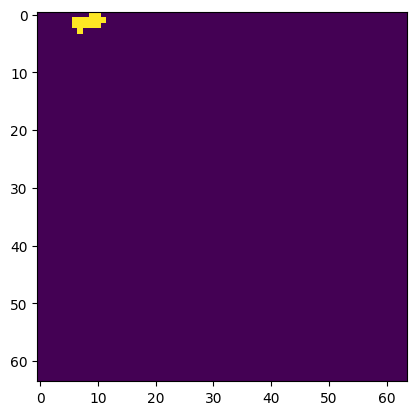

In [44]:
import matplotlib.pyplot as plt
plt.imshow(masks["roi_mask"] == -10)